

ENERGIA SOLAR

LUIZ LAMPREIA NETO - TURMA 03D - 20160124980


**Introdução:**

Este trabalho corresponde a uma análise de dados através dos pontos que relacionam horário do dia com a quntidade de energia(potência ativa) gerada em um dia, observando o comportamento ao longo das horas. Através do gráfico podemos utilizar o MÉTODO das RAÍZES, especificamente bissecção para inferir a quantidade de energia gerada em um horário informado pelo usuário. Podemos utilizar o MMQ(mínimos quadrados) para analisar melhor os dados, verificando o polinômio no intervalo informado. Por conseguinte, a regra de Simpson(integração) será utilizada para medir a área aproximada do gráfico e teremos a geração total de energia.

DADOS BRUTOS:

O gráfico a seguir foi gerado a partir de dados coletados em uma empresa, essa empresa trabalha com enrgias renováveis, solar e eólicas, nesse exemplo, utilizaremos a energia solar para analizar os dados e aplicar os métodos. Tendo em vista que se trata de energia solar e placas solares a potência ativa durante o período da noite é nula, os daos mais relevantes para a nossa análise são diurnos, é importante destacar.

<ipython-input-14-7ca834cc6cb1>:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


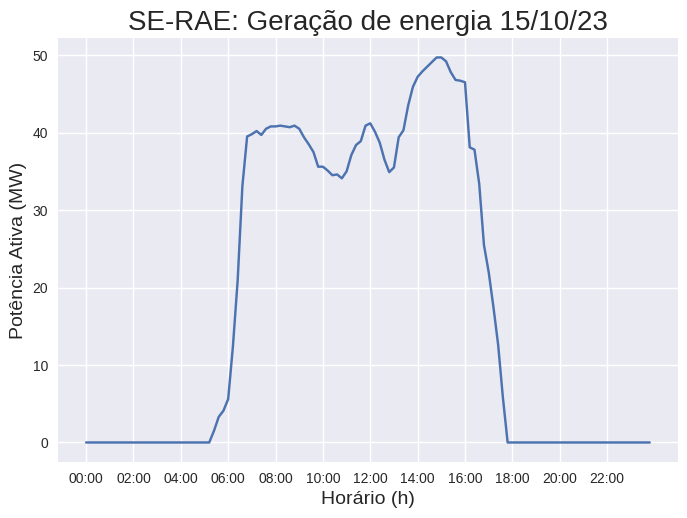

In [ ]:
import matplotlib.pyplot as plt

plt.clf()
plt.style.use("seaborn")
plt.title("SE-RAE: Geração de energia 15/10/23",fontsize=20)
plt.ylabel('Potência Ativa (MW)',fontsize=14)
plt.xlabel('Horário (h)',fontsize=14)

y = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
     0,0,0,0,0,0,0,0,0,0,1.5,3.3,4.1,
     5.6,12.4,20.9,33.1,39.5,39.8,40.2,39.7,40.5,
     40.8,40.8,40.9,40.8,40.7,40.9,40.5,39.4,
     38.5,37.5,35.6,35.6,35.1,34.5,34.6,34.1,
     35,37.1,38.4,38.9,40.9,41.2,40.1,38.7,36.5,
     34.9,35.5,39.4,40.3,43.5,45.9,47.2,47.9,48.5,
     49.1,49.7,49.7,49.2,47.8,46.8,46.7,46.5,38.1,
     37.8,33.4,25.5,22,17.5,12.6,5.8,0,0,0,0,0,0,0,
     0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]


x = ['00:00','00:12','00:24','00:36','00:48','01:00','01:12','01:24',
     '01:36','01:48','02:00','02:12','02:24','02:36','02:48','03:00',
     '03:12','03:24','03:36','03:48','04:00','04:12','04:24','04:36',
     '04:48','05:00','05:12','05:24','05:36','05:48','06:00','06:12',
     '06:24','06:36','06:48','07:00','07:12','07:24','07:36','07:48',
     '08:00','08:12','08:24','08:36','08:48','09:00','09:12','09:24',
     '09:36','09:48','10:00','10:12','10:24','10:36','10:48','11:00',
     '11:12','11:24','11:36','11:48','12:00','12:12','12:24','12:36',
     '12:48','13:00','13:12','13:24','13:36','13:48','14:00','14:12',
     '14:24','14:36','14:48','15:00','15:12','15:24','15:36','15:48',
     '16:00','16:12','16:24','16:36','16:48','17:00','17:12','17:24',
     '17:36','17:48','18:00','18:12','18:24','18:36','18:48','19:00',
     '19:12','19:24','19:36','19:48','20:00','20:12','20:24','20:36',
     '20:48','21:00','21:12','21:24','21:36','21:48','22:00','22:12',
     '22:24','22:36','22:48','23:00','23:12','23:24','23:36','23:48']


plt.plot(x,y)
plt.xticks(x[::10])
plt.show()

Observação: segundo método foi substituído por MMQ.

*aplicações*:

MÉTODO 1: raízes para inferir a quantidde de energia em um horário específico.

MÉTODO 2: MMQ para gerar o polinomio da aproximacao.

MÉTODO 3: integração, aproximacao da área do gráfico, geração total.

RESULTADOS:

MÉTODO 1 - RAÍZES(BISSECCAO)



In [ ]:
import math


a = 5.12
b = 6.48
e = 0.01

def f(x):
  return   -5.64*(x**2) + 91.7 *x - 323.83 # polinomio aproximado encontardo por MMQ; método 2

if f(a)*f(b) < 0:    # bolzano; condicao
  while(math.fabs(b-a)/2 > e):
    xi = (a+b)/2
    if f(xi) == 0 :
      print("a raiz é:", xi)
      break
    else:
      if f(a)*f(xi) < 0: # bolzano; condicao
        b = xi
      else:
        a = xi
  print("valor da potência ativa no intervalo do horário é: ", xi)

else:
  print("não há valor nesse intervalo")

valor da potência ativa no intervalo do horário é:  5.194375


Podemos observar que a potência no intervalo escolhido foi de 5.19w ,aproximadamente. Com esse método podemos estimar o valor da potência gerada em um intervalo escolhido pelo cliente. Lembrando que os horários de cada geração são definidos pelo eixo x no gráfico. Devemos aplicar Bolzano no algoritmo. Definimos um erro de 0.01 que também poderá ser escolhido pelo cliente, ficando a seu critério, a precisão. Para realizar o método precisei de outro que é o MMQ, a fim de achar o polinômio que se aproxima da curva através de métodos vistos em sala.

MÉTODO 2 - MMQ

In [ ]:
import numpy as np

def matrizAumentada(x,y,dim):
  m = len(x) # tamanho dos dados
  A = np.empty((dim,dim))
  b = np.empty((dim))
  soma = []
  for i in range(0,dim+2):
    aux = 0
    for k in range(0,m):
      aux = aux + x[k]**i
    soma.append(aux)

  for i in range(0,dim):
    for j in range(i,dim):
      A[i,j] = soma[i+j]
      if (i != j):
        A[j,i] = A[i,j]

  b = []
  for i in range(0,dim):
    aux = 0
    for k in range(0,m):
      aux = aux + y[k]*(x[k]**(i)) # soma e produto na matriz aumentada
    b.append(aux)

  return A,b


x = [5.12,5.24,5.36,5.48,6.00,6.12,6.24,6.36,6.48,7.00,7.12] # dados com os horarios para aprox
y = [1.5,3.3,4.1,5.6,12.4,20.9,33.1,39.5,39.8,40.2,39.7] # potencia ativa gerada no intervalo
A,b = matrizAumentada(x,y,3)
print("A = ", A)
print("b = ", b)
coef = np.linalg.solve(A,b) # coeficientes do polinomio
print("coef = ",coef)

A =  [[1.10000000e+01 6.65200000e+01 4.06958400e+02]
 [6.65200000e+01 4.06958400e+02 2.51814573e+03]
 [4.06958400e+02 2.51814573e+03 1.57535842e+04]]
b =  [240.09999999999997, 1559.676, 10185.2696]
coef =  [-323.83690541   91.70054748   -5.64582144]


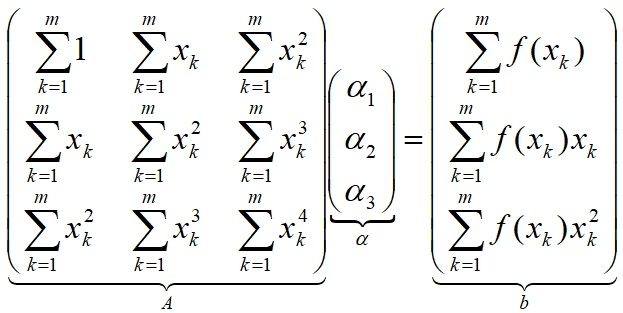

Nesse método foi utilizado mínimos quadrados, tendo em vista que não comhecemos a funcao que representa a curva no gráfico, mas, temos os pontos, com isso, podemos definir um polinômio que vai se aproximar dessa curva no ponto que escolher-mos.

Através da quantidade de dados provenientes do eixo x podemos definir o tamanho e trabalhar com a dimensão do sistema aumentado, dentro da respectiva funcao "matrizAumentada".

Saving trabalho energia.png to trabalho energia.png


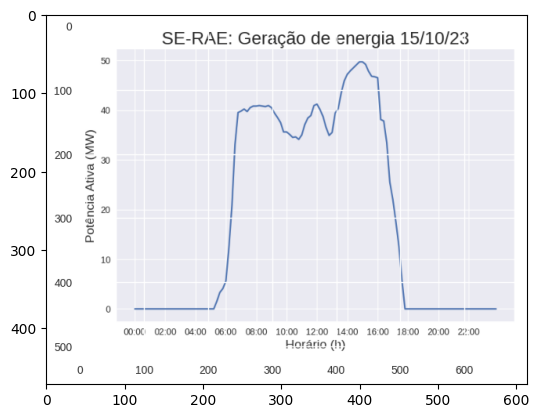

In [ ]:
#Importar módulos
from google.colab import files
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
uploaded = files.upload()
filename = next(iter(uploaded)) #pegar o nome do arquivo
img = Image.open(BytesIO(uploaded[filename]))

plt.imshow(img)

Temos acima, o que foi trabalhado e analisado em laboratório.

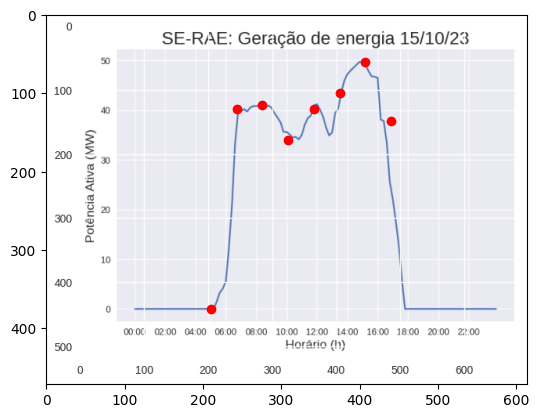

In [ ]:
plt.imshow(img)

x=np.linspace(210,440,8) # 8 pontos escolhidos para aproximacao
ys=np.array([375,120,115,160,120,100,60,135]) # pontos escolhidos
plt.plot(x,ys,'ro')


plt.show()


Utilizamos a parte superior do gráfico para aproximar os pontos à curva, a fim de aplicarmos o método da integracao com trapézios e acharmos a area aproximada do gráfico, e com isso, teremos uma estiva da potencia total gerada caso não tivessemos todos os valores em y.

In [ ]:
x =np.linspace(210,440,8)
print(x)

[210.         242.85714286 275.71428571 308.57142857 341.42857143
 374.28571429 407.14285714 440.        ]


Metodo 3 - Integração

In [ ]:
def trap (x1, x2,y1,y2):
  a = (y2+y1)*(x2-x1)/2
  return a
def areatrap(x,y):
  a=0
  for i in range(len(x) - 1):
    a=a+trap(x[i],x[i+1],y[i],y[i+1])
  return a
trapsup=areatrap(x,ys)
areatrapezio = (trapsup)/15
potencia_real = 2199 # potencia da soma total dos valores em y(geracao total de todo o gráfico)
print("potência aproximada em MW: ", round(areatrapezio,2))
print("potencia real em MW: ", potencia_real)

potência aproximada em MW:  2037.14
potencia real em MW:  2199


Por fim, faremos uma análise comparando o valor da aproximacao com os dados reais obtidos com o somatório das potencias no eixo y em cada respectivo horário. Considerando que a relacao deu um valor igual a 15 devido aos pixels da imagem, sua proporcao e escala.

referências: LA e Soluções, 20/11/2023.